Encoder-only Transformer for binary Sentiment Classification — Task 1.2.

Architecture (Karpathy NanoGPT-inspired, adapted for classification):
 - Token embedding + learned positional embedding
 - Prepended learnable [CLS] token (BERT-style pooling)
 - N x EncoderBlock: MultiHeadSelfAttention → Pre-LN → FFN → Pre-LN
 - Classification head on CLS output

Outputs saved to ./model/:
 - transformer_sentiment.pt  — model weights + config
 - vocab.pkl                 — serialised Vocabulary object

In [ ]:
import sys
import os
import time
import datetime
from typing import Optional
from dataclasses import dataclass
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, classification_report

sys.path.insert(0, os.path.join(os.getcwd(), "utils"))  # jupyter path fix
from utils.preprocessing import load_data, MAX_SEQ_LEN, PAD_IDX, MODEL_DIR

In [3]:
@dataclass
class TransformerConfig:
    vocab_size: int = 5000  # updated from actual vocab after data load
    n_classes: int = 2
    max_seq_len: int = MAX_SEQ_LEN  # 64
    d_model: int = 128  # embedding / hidden dimension
    n_heads: int = 4  # attention heads (d_model % n_heads == 0)
    n_layers: int = 2  # number of encoder blocks
    d_ff: int = 256  # FFN inner dimension (2×–4× d_model)
    dropout: float = 0.1
    pad_idx: int = PAD_IDX

In [4]:
# Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product multi-head self-attention with key-padding mask."""

    def __init__(self, cfg: TransformerConfig):
        super().__init__()
        assert cfg.d_model % cfg.n_heads == 0, "d_model must be divisible by n_heads"
        self.d_k = cfg.d_model // cfg.n_heads
        self.n_heads = cfg.n_heads
        self.W_q = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.W_k = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.W_v = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.W_o = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.attn_drop = nn.Dropout(cfg.dropout)

    def forward(
        self, x: torch.Tensor, key_padding_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        B, T, _ = x.shape
        H, d_k = self.n_heads, self.d_k
        Q = self.W_q(x).view(B, T, H, d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, H, d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, H, d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) * (d_k**-0.5)
        if key_padding_mask is not None:
            scores = scores.masked_fill(
                key_padding_mask[:, None, None, :], float("-inf")
            )
        attn = self.attn_drop(F.softmax(scores, dim=-1))
        out = (attn @ V).transpose(1, 2).contiguous().view(B, T, H * d_k)
        return self.W_o(out)


# Feed-Forward Network
class FeedForward(nn.Module):
    """Position-wise FFN: Linear → GELU → Dropout → Linear → Dropout."""

    def __init__(self, cfg: TransformerConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_ff),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_ff, cfg.d_model),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Encoder Block (Pre-LayerNorm)
class EncoderBlock(nn.Module):
    """MHA -> Add+Norm -> FFN -> Add+Norm (Pre-LN formulation)."""

    def __init__(self, cfg: TransformerConfig):
        super().__init__()
        self.attn = MultiHeadSelfAttention(cfg)
        self.ffn = FeedForward(cfg)
        self.norm1 = nn.LayerNorm(cfg.d_model)
        self.norm2 = nn.LayerNorm(cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(
        self, x: torch.Tensor, key_padding_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        x = x + self.drop(self.attn(self.norm1(x), key_padding_mask))
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x


# Full Model
class SentimentTransformer(nn.Module):
    """
    Encoder-only Transformer classifier.
    A learned [CLS] token is prepended; its final representation feeds the head.
    """

    def __init__(self, cfg: TransformerConfig):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(cfg.max_seq_len + 1, cfg.d_model)  # +1 for CLS
        self.cls_tok = nn.Parameter(torch.zeros(1, 1, cfg.d_model))
        self.layers = nn.ModuleList([EncoderBlock(cfg) for _ in range(cfg.n_layers)])
        self.norm = nn.LayerNorm(cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.classifier = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model // 2),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_model // 2, cfg.n_classes),
        )
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                with torch.no_grad():
                    self.tok_emb.weight[PAD_IDX].zero_()

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        """
        input_ids : (B, T) — integer token ids padded to MAX_SEQ_LEN
        returns   : (B, n_classes) raw logits
        """
        B, T = input_ids.shape
        positions = torch.arange(1, T + 1, device=input_ids.device).unsqueeze(0)
        x = self.drop(self.tok_emb(input_ids) + self.pos_emb(positions))
        cls = self.cls_tok.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        pad_mask = torch.cat(
            [
                torch.zeros(B, 1, dtype=torch.bool, device=input_ids.device),
                input_ids == PAD_IDX,
            ],
            dim=1,
        )
        for layer in self.layers:
            x = layer(x, key_padding_mask=pad_mask)
        cls_out = self.norm(x[:, 0, :])
        return self.classifier(cls_out)

In [ ]:
def evaluate(model: nn.Module, loader, device: torch.device):
    """Evaluate model; uses plain CrossEntropyLoss (no smoothing) for comparable numbers."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    criterion = (
        nn.CrossEntropyLoss()
    )  # no label_smoothing here — keeps val loss interpretable

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item()
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        all_preds,
        all_labels,
    )


def train(
    data_file: str = "amazon_cells_labelled.txt",
    n_epochs: int = 60,
    batch_size: int = 32,
    lr: float = 3e-4,
    d_model: int = 128,
    n_heads: int = 4,
    n_layers: int = 2,
    d_ff: int = 256,
    dropout: float = 0.1,
    max_seq_len: int = MAX_SEQ_LEN,
    early_stopping_patience: int = 8,  # halt when val acc stagnates for N epochs
    label_smoothing: float = 0.1,  # penalises overconfident predictions
    weight_decay: float = 1e-2,
    model_dir: str = MODEL_DIR,  # ./model
    log_dir: str = "runs/transformer",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[transformer] Device            : {device}")

    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, "transformer_sentiment.pt")
    vocab_path = os.path.join(model_dir, "vocab.pkl")
    print(f"[transformer] Model checkpoint  : {model_path}")
    print(f"[transformer] Vocabulary        : {vocab_path}")

    run_name = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    writer = SummaryWriter(log_dir=f"{log_dir}/{run_name}")
    print(f"[transformer] TensorBoard log   : {log_dir}/{run_name}")
    print(f"              Launch with       : tensorboard --logdir {log_dir}\n")

    train_loader, val_loader, test_loader, vocab = load_data(
        filepath=data_file,
        remove_stopwords=False,
        max_seq_len=max_seq_len,
        batch_size=batch_size,
        save_vocab=True,
        vocab_path=vocab_path,  # saved to ./model/vocab.pkl
    )

    cfg = TransformerConfig(
        vocab_size=len(vocab),
        n_classes=2,
        max_seq_len=max_seq_len,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
    )
    model = SentimentTransformer(cfg).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[transformer] Trainable params  : {n_params:,}")
    print(f"[transformer] Config            : {cfg}\n")

    # Log model graph once
    dummy = torch.zeros(1, max_seq_len, dtype=torch.long, device=device)
    writer.add_graph(model, dummy)

    # Optimiser
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)

    best_val_acc = 0.0
    best_state = None
    patience_ctr = 0

    # Training loop
    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        t0 = time.time()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        train_loss = epoch_loss / len(train_loader)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, device)
        current_lr = scheduler.get_last_lr()[0]
        elapsed = time.time() - t0

        # TensorBoard scalars
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)
        writer.add_scalar("LR", current_lr, epoch)
        writer.add_scalar("Grad_Norm", grad_norm, epoch)

        marker = " ◀ best" if val_acc > best_val_acc else ""
        print(
            f"Epoch {epoch:3d}/{n_epochs} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f} | Acc: {val_acc:.4f} | "
            f"{elapsed:.1f}s{marker}"
        )

        # Checkpoint + early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= early_stopping_patience:
                print(
                    f"\n[early stop] No val acc improvement for "
                    f"{early_stopping_patience} epochs — stopping at epoch {epoch}."
                )
                break

    # Final test evaluation
    print("\n--- Test Set Evaluation (best checkpoint) ---")
    model.load_state_dict(best_state)
    _, test_acc, test_preds, test_labels = evaluate(model, test_loader, device)
    print(f"Test Accuracy : {test_acc:.4f}\n")
    print(
        classification_report(
            test_labels, test_preds, target_names=["Negative (0)", "Positive (1)"]
        )
    )

    # Log hyperparameters + final metrics for the hparams dashboard
    writer.add_hparams(
        {
            "d_model": d_model,
            "n_heads": n_heads,
            "n_layers": n_layers,
            "d_ff": d_ff,
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "label_smoothing": label_smoothing,
            "weight_decay": weight_decay,
        },
        {"hparam/test_acc": test_acc, "hparam/best_val_acc": best_val_acc},
    )
    writer.close()

    torch.save({"model_state": best_state, "config": cfg}, model_path)
    print(f"[transformer] Model saved  → {model_path}")
    print(f"[transformer] Vocab saved  → {vocab_path}")
    return model, vocab

In [8]:
model, vocab = train(
    data_file="data/amazon_cells_labelled_LARGE_25K.txt",
    n_epochs=60,
    batch_size=32,
    lr=3e-5,
    d_model=64,
    n_heads=4,
    n_layers=1,
    d_ff=128,
    dropout=0.4,
    max_seq_len=MAX_SEQ_LEN,
    early_stopping_patience=8,
    label_smoothing=0.1,
    weight_decay=1e-2,
    model_dir="model",  # → ./model/
    log_dir="runs/transformer",
)

[transformer] Device            : cuda
[transformer] Model checkpoint  : model/transformer_sentiment.pt
[transformer] Vocabulary        : model/vocab.pkl
[transformer] TensorBoard log   : runs/transformer/20260412_133334
              Launch with       : tensorboard --logdir runs/transformer

[transformer] Trainable params  : 615,842
[transformer] Config            : TransformerConfig(vocab_size=9002, n_classes=2, max_seq_len=64, d_model=64, n_heads=4, n_layers=1, d_ff=128, dropout=0.4, pad_idx=0)

Epoch   1/60 | Train: 0.9319 | Val: 0.6756 | Acc: 0.6048 | 2.7s ◀ best
Epoch   2/60 | Train: 0.7555 | Val: 0.6699 | Acc: 0.6048 | 2.6s
Epoch   3/60 | Train: 0.7089 | Val: 0.6752 | Acc: 0.6048 | 2.4s
Epoch   4/60 | Train: 0.6830 | Val: 0.6502 | Acc: 0.6212 | 2.3s ◀ best
Epoch   5/60 | Train: 0.6652 | Val: 0.6077 | Acc: 0.6952 | 2.3s ◀ best
Epoch   6/60 | Train: 0.6488 | Val: 0.5612 | Acc: 0.7228 | 2.5s ◀ best
Epoch   7/60 | Train: 0.6325 | Val: 0.5196 | Acc: 0.7336 | 2.7s ◀ best
Epoch   8/60 

In [ ]:
# # %load_ext tensorboard
# %tensorboard --logdir runs

Reusing TensorBoard on port 6006 (pid 75836), started 0:00:15 ago. (Use '!kill 75836' to kill it.)

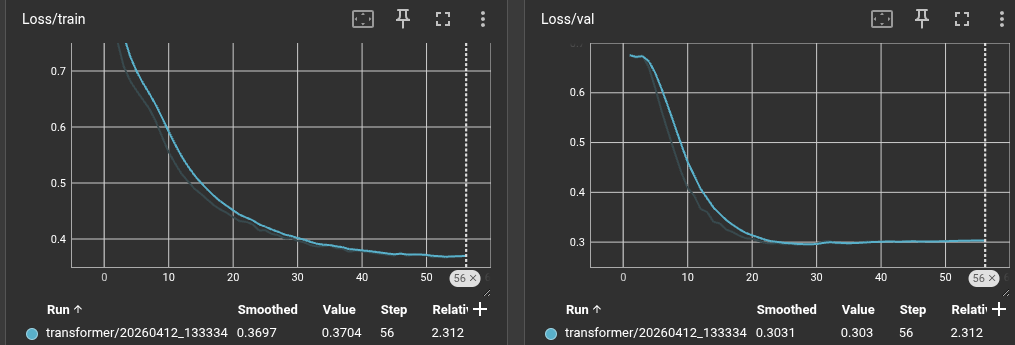